In [2]:

import requests
import polars as pl
import json
import re
import html

In [ ]:
# Передаем наш API_KEY. Лучше считывать из txt-файла
API_KEY = "вбить свой ключ"  # получить на apidata.mos.ru
# Получаем список датасетов. Важно! Как узнать что мы передаем в post? - смотрим документацию
# 1. Список датасетов (id, название, описание)
resp = requests.post(
    "https://apidata.mos.ru/v1/datasets",
    params={"api_key": API_KEY, "$top": 100}  # можно убрать $top, чтобы получить все
)
# Наши данные лежат в json-файле по ключу - Items. считываем.
datasets = resp.json()["Items"]

In [4]:
# Переводим в формата объекта датафрейма polars
df = pl.DataFrame([
    {"Id": d["Id"], "Caption": d.get("Caption"), "Description": d.get("FullDescription")}
    for d in datasets
])
df[:3]

Id,Caption,Description
i64,str,str
1798,"""Закусочные""","""<p style=""margin-left:0cm; mar…"
61801,"""Зимние активности парков, подв…","""<p>Набор данных содержит инфор…"
2356,"""Кабинеты иммунопрофилактики""","""<p>Набор данных &lt;&lt;Кабине…"


In [5]:
# Посмотрим сколько у нас датасетов. Вопрос, почему их 100? как изменить это?
df.n_unique()

100

In [6]:
# добавляем очистку описания в столбце Description (оно имеет html формат, поэтому используем соотвествующую библиотеку)
df = df.with_columns(
    pl.col("Description")
    .map_elements(lambda x: re.sub(r"<[^>]+>", "", html.unescape(x)) if x else x, return_dtype=pl.Utf8)
    .str.strip_chars()
    .alias("Description")
)

In [7]:
df[:3]

Id,Caption,Description
i64,str,str
1798,"""Закусочные""","""Предприятие (объект) питания с…"
61801,"""Зимние активности парков, подв…","""Набор данных содержит информац…"
2356,"""Кабинеты иммунопрофилактики""","""Набор данных > позволяет получ…"


In [8]:
# 2. Скачивание конкретного датасета по id (например, 61801)
dataset_id = 61801 #это наша переменная, котоую мы можем вставить в тело запроса, используя синтаксис {}
rows_resp = requests.get(
    f"https://apidata.mos.ru/v1/datasets/{dataset_id}/rows",
    params={"api_key": API_KEY}
)
# Получаем наша набор данных. Он в json
rows = rows_resp.json()

In [9]:
rows

[{'global_id': 2836096659,
  'Number': 1,
  'Cells': {'global_id': 2836096659,
   'ID': 211,
   'AdmArea': 'Северо-Западный административный округ',
   'District': 'район Митино',
   'NameOfPark': {'value': 'Ландшафтный парк «Митино»', 'global_id': 4331832},
   'ObjectType': 'каток с искусственным покрытием',
   'Name': 'Каток в ландшафтном парке «Митино»',
   'Location': 'ул. Пенягинская, д.16',
   'Longitude_WGS84': '37.363983',
   'Latitude_WGS84': '55.835532',
   'WorkingHours': '10:00-21:00 (понедельник - санитарный день)',
   'PaidService': 'платно',
   'InventoryRental': 'да',
   'HasDressingRoom': 'да',
   'SharpeningSkates': 'да',
   'HireSkatersAssistants': 'да',
   'Square': 4000,
   'Length': None,
   'LightingAvailability': None}},
 {'global_id': 2836096669,
  'Number': 2,
  'Cells': {'global_id': 2836096669,
   'ID': 190,
   'AdmArea': 'Северо-Западный административный округ',
   'District': 'район Митино',
   'NameOfPark': {'value': 'Ландшафтный парк «Митино»', 'global_i

In [ ]:
# у каждой строки данные лежат в поле "Cells"
data_df = pl.DataFrame([
    {k: (json.dumps(v, ensure_ascii=False) if isinstance(v, (list, dict)) else v)
     for k, v in row["Cells"].items()}
    for row in rows
])

data_df.write_excel(f"dataset_{dataset_id}.csv")

isinstance(v, (list, dict)) — проверяет, является ли v списком или словарём (вторым аргументом передаётся кортеж типов — проверка сразу по нескольким типам).

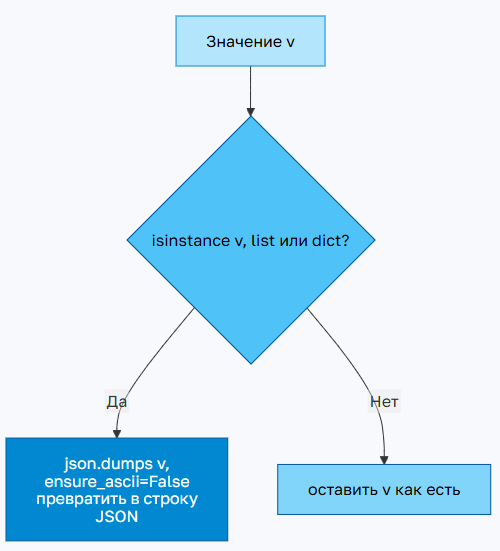


Если да (например,
v = ["123-45-67", "890-12-34"]
) → выполняется json.dumps(v, ensure_ascii=False), что превращает список/словарь в строку JSON:
json.dumps(["123-45-67", "890-12-34"], ensure_ascii=False)
# результат: '["123-45-67", "890-12-34"]'   (это уже обычная строка!)

Зачем это нужно: библиотека polars (и формат CSV) не умеет напрямую хранить вложенные списки/словари в ячейке таблицы — при попытке сохранить такие данные возникает ошибка